##IMPORT

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import numpy as np
from google.colab import drive

# 1. Mount Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Configuration - UPDATE THESE PATHS

In [ ]:
ROOT_PATH = '/content/drive/MyDrive/Distance_classification'  # Folder containing 10, 20, 30, 40, 50
REFERENCE_IMAGE_PATH = '/content/drive/MyDrive/Distance_classification/reference.jpg' # Your reference image
IMG_SIZE = 224
ROI = (50, 200, 50, 200) # y1, y2, x1, x2 (Adjust based on your speckle location)

# 3. Dataset Logic with ZNCC & ROI

In [ ]:
class SpeckleDistanceDataset(Dataset):
    def __init__(self, root_dir, ref_path, img_size=IMG_SIZE, roi_coords=ROI):
        self.root_dir = root_dir
        self.roi = roi_coords
        self.img_size = img_size
        self.classes = ['10', '20', '30', '40', '50']
        self.data = []

        ref_img = Image.open(ref_path).convert('L')
        ref_tensor = transforms.ToTensor()(ref_img)
        self.ref_roi = self._extract_roi(ref_tensor)

        for idx, cls in enumerate(self.classes):
            cls_folder = os.path.join(root_dir, cls)
            if not os.path.exists(cls_folder): continue
            for img_name in os.listdir(cls_folder):
                self.data.append((os.path.join(cls_folder, img_name), idx))

    def _extract_roi(self, img):
        y1, y2, x1, x2 = self.roi
        return img[:, y1:y2, x1:x2]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert('L')
        img_tensor = transforms.ToTensor()(img)

        img_roi = self._extract_roi(img_tensor)

        # Zero-mean Normalization (ZNCC Pre-step)
        img_roi = (img_roi - img_roi.mean()) / (img_roi.std() + 1e-8)
        ref_roi_norm = (self.ref_roi - self.ref_roi.mean()) / (self.ref_roi.std() + 1e-8)

        # Stack as 2-channel input
        combined = torch.cat([img_roi, ref_roi_norm], dim=0)
        combined = transforms.Resize((self.img_size, self.img_size))(combined)

        return combined, label

# 4. ResNet-9 Architecture

In [ ]:
def conv_block(in_f, out_f, pool=False):
    layers = [nn.Conv2d(in_f, out_f, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_f),
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))
        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d(1), nn.Flatten(),
                                        nn.Dropout(0.2), nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        return self.classifier(out)

# 5. Training and Efficiency Loop

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
full_dataset = SpeckleDistanceDataset(ROOT_PATH, REFERENCE_IMAGE_PATH)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_set, test_set = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = DataLoader(test_set, batch_size=4)

model = ResNet9(in_channels=2, num_classes=5).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, pred = torch.max(model(imgs), 1)
            correct += (pred == labels).sum().item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.3f} | Accuracy: {100*correct/test_size:.1f}%")

Epoch 1 | Loss: 4.115 | Accuracy: 33.3%
Epoch 2 | Loss: 0.758 | Accuracy: 0.0%
Epoch 3 | Loss: 0.147 | Accuracy: 0.0%
Epoch 4 | Loss: 0.085 | Accuracy: 0.0%
Epoch 5 | Loss: 0.088 | Accuracy: 0.0%
Epoch 6 | Loss: 0.029 | Accuracy: 0.0%
Epoch 7 | Loss: 0.021 | Accuracy: 0.0%
Epoch 8 | Loss: 0.007 | Accuracy: 0.0%
Epoch 9 | Loss: 0.003 | Accuracy: 0.0%
Epoch 10 | Loss: 0.004 | Accuracy: 0.0%


VGGNet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROI Detected: x=931, y=1968, w=869, h=854
Loading 10m: 12 images
Loading 20m: 12 images
Loading 30m: 12 images
Loading 40m: 12 images
Loading 50m: 12 images
Total Dataset: 60 images.

Starting Training...
Epoch 01 | Loss: 1.6434 | Test Acc: 16.7%
Epoch 02 | Loss: 1.6149 | Test Acc: 16.7%
Epoch 03 | Loss: 1.6133 | Test Acc: 16.7%
Epoch 04 | Loss: 1.6118 | Test Acc: 16.7%
Epoch 05 | Loss: 1.6097 | Test Acc: 16.7%
Epoch 06 | Loss: 1.6066 | Test Acc: 16.7%
Epoch 07 | Loss: 1.6054 | Test Acc: 33.3%
Epoch 08 | Loss: 1.6140 | Test Acc: 16.7%
Epoch 09 | Loss: 1.6058 | Test Acc: 16.7%
Epoch 10 | Loss: 1.6080 | Test Acc: 16.7%
Epoch 11 | Loss: 1.5968 | Test Acc: 16.7%
Epoch 12 | Loss: 1.5968 | Test Acc: 16.7%
Epoch 13 | Loss: 1.5980 | Test Acc: 33.3%
Epoch 14 | Loss: 1.6051 | Test Acc: 16.7%
Epoch 15 | Loss: 1.5666 | Test Acc: 41.7%
Epoch 16 | Loss: 1.5948 | Test Acc: 

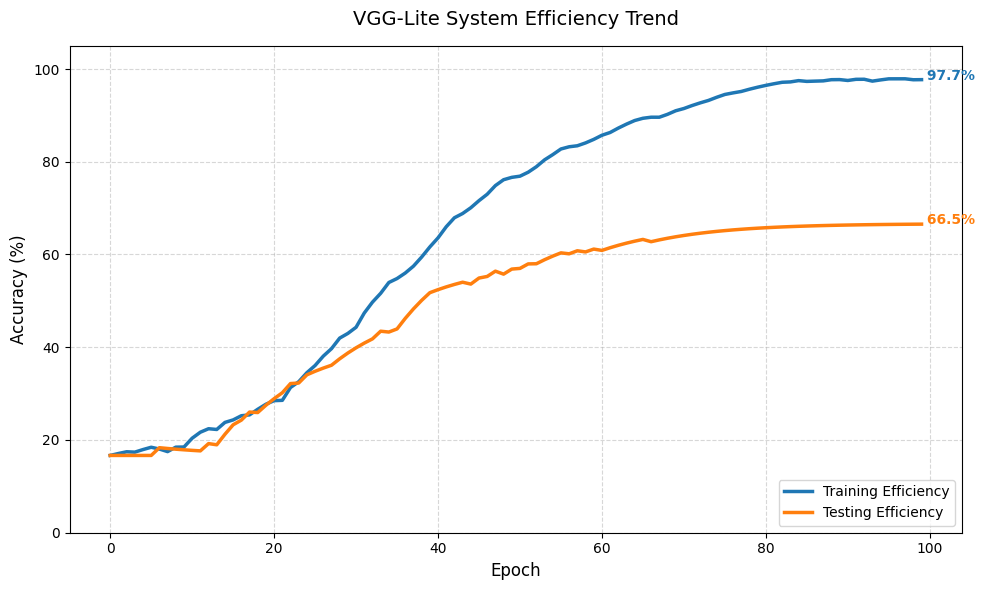

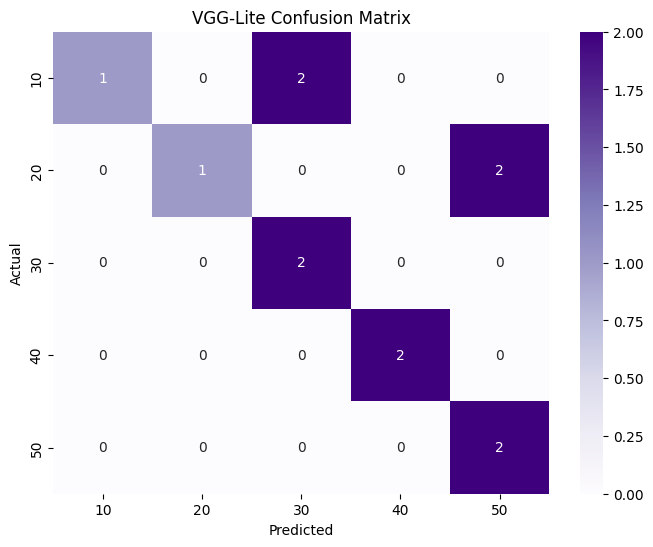

In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from google.colab import drive

# 1. Setup & Paths
drive.mount('/content/drive')
ROOT_PATH = '/content/drive/MyDrive/Distance_classification'
REF_PATH = '/content/drive/MyDrive/Distance_classification/reference.jpg'
CLASSES = ['10', '20', '30', '40', '50']

# --- Helper Functions ---
def get_roi_coords(image_path):
    img = cv2.imread(image_path, 0)
    if img is None: raise FileNotFoundError(f"Check path: {image_path}")
    _, thresh = cv2.threshold(img, 20, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        return cv2.boundingRect(c)
    return (0, 0, img.shape[1], img.shape[0])

def smoothen(data, weight=0.9):
    """Calculates exponential moving average for a smooth curve."""
    last = data[0]
    smoothed = []
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# --- Dataset Class ---
class DynamicSpeckleDataset(Dataset):
    def __init__(self, root, ref_path):
        self.samples = []
        x, y, w, h = get_roi_coords(ref_path)
        print(f"ROI Detected: x={x}, y={y}, w={w}, h={h}")

        # Process Reference ROI
        ref_img = np.array(Image.open(ref_path).convert('L'))[y:y+h, x:x+w]
        ref_t = transforms.ToTensor()(Image.fromarray(ref_img))
        self.ref_norm = (ref_t - ref_t.mean()) / (ref_t.std() + 1e-8)

        for idx, cls in enumerate(CLASSES):
            folder = os.path.join(root, cls)
            if not os.path.exists(folder): continue
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print(f"Loading {cls}m: {len(files)} images")
            for img_name in files:
                img_path = os.path.join(folder, img_name)
                img = np.array(Image.open(img_path).convert('L'))[y:y+h, x:x+w]
                img_t = transforms.ToTensor()(Image.fromarray(img))
                norm = (img_t - img_t.mean()) / (img_t.std() + 1e-8)

                # Combine Target and Reference as 2 channels
                combined = torch.cat([norm, self.ref_norm], dim=0)
                self.samples.append((transforms.Resize((224, 224))(combined), idx))
        print(f"Total Dataset: {len(self.samples)} images.")

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

# --- VGG-Lite Model ---
class VGG_Speckle(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(True), nn.AdaptiveAvgPool2d((7, 7))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(512, 5)
        )
    def forward(self, x): return self.classifier(self.features(x))

# --- Execution ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = DynamicSpeckleDataset(ROOT_PATH, REF_PATH)
train_size = int(0.8 * len(dataset))
train_set, test_set = random_split(dataset, [train_size, len(dataset) - train_size])

train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1)

model = VGG_Speckle().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

history = {'loss': [], 'train_acc': [], 'test_acc': []}

print("\nStarting Training...")
for epoch in range(100):
    model.train()
    running_loss, train_correct = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_correct += (torch.max(outputs, 1)[1] == labels).sum().item()

    model.eval()
    test_correct = sum((torch.max(model(im.to(device)), 1)[1] == la.to(device)).item() for im, la in test_loader)

    history['loss'].append(running_loss/len(train_loader))
    history['train_acc'].append(100*train_correct/len(train_set))
    history['test_acc'].append(100*test_correct/len(test_set))
    print(f"Epoch {epoch+1:02d} | Loss: {history['loss'][-1]:.4f} | Test Acc: {history['test_acc'][-1]:.1f}%")

# --- FINAL RESULTS & SMOOTHED GRAPH ---
print("\nGenerating Final Analytics...")
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for im, la in test_loader:
        y_true.append(la.item())
        y_pred.append(torch.max(model(im.to(device)), 1)[1].item())

# 1. Performance Report
print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, labels=np.arange(len(CLASSES)), target_names=CLASSES, zero_division=0))

# 2. Plotting Only Smoothed Efficiency
smooth_train = smoothen(history['train_acc'], weight=0.9)
smooth_test = smoothen(history['test_acc'], weight=0.9)

plt.figure(figsize=(10, 6))
plt.plot(smooth_train, color='#1f77b4', linewidth=2.5, label='Training Efficiency')
plt.plot(smooth_test, color='#ff7f0e', linewidth=2.5, label='Testing Efficiency')

# Annotation for Final Values
plt.text(len(smooth_train)-1, smooth_train[-1], f" {smooth_train[-1]:.1f}%", color='#1f77b4', fontweight='bold')
plt.text(len(smooth_test)-1, smooth_test[-1], f" {smooth_test[-1]:.1f}%", color='#ff7f0e', fontweight='bold')

plt.title('VGG-Lite System Efficiency Trend', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASSES)))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Purples')
plt.title('VGG-Lite Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ResNet-9

In [ ]:
import os, torch, torch.nn as nn, torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from google.colab import drive

# 1. Setup & Paths
drive.mount('/content/drive')
ROOT_PATH = '/content/drive/MyDrive/Distance_classification'
REF_PATH = '/content/drive/MyDrive/Distance_classification/reference.jpg'
CLASSES = ['10', '20', '30', '40', '50']

# --- Utility Functions ---
def get_roi_coords(image_path):
    img = cv2.imread(image_path, 0)
    if img is None: raise FileNotFoundError(f"Check path: {image_path}")
    _, thresh = cv2.threshold(img, 20, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        return cv2.boundingRect(c)
    return (0, 0, img.shape[1], img.shape[0])

def smoothen(data, weight=0.85):
    last = data[0]
    smoothed = []
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# --- Dataset Class ---
class SpeckleDataset(Dataset):
    def __init__(self, root, ref_path):
        self.samples = []
        x, y, w, h = get_roi_coords(ref_path)
        print(f"ROI Detected: x={x}, y={y}, w={w}, h={h}")

        ref_img = np.array(Image.open(ref_path).convert('L'))[y:y+h, x:x+w]
        ref_t = transforms.ToTensor()(Image.fromarray(ref_img))
        self.ref_norm = (ref_t - ref_t.mean()) / (ref_t.std() + 1e-8)

        for idx, cls in enumerate(CLASSES):
            folder = os.path.join(root, cls)
            if not os.path.exists(folder): continue
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print(f"Loading {cls}m: {len(files)} images")
            for img_name in files:
                img = np.array(Image.open(os.path.join(folder, img_name)).convert('L'))[y:y+h, x:x+w]
                img_t = transforms.ToTensor()(Image.fromarray(img))
                norm = (img_t - img_t.mean()) / (img_t.std() + 1e-8)
                combined = torch.cat([norm, self.ref_norm], dim=0)
                self.samples.append((transforms.Resize((224, 224))(combined), idx))

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

# --- ResNet-9 Architecture ---
def conv_block(in_f, out_f, pool=False):
    layers = [nn.Conv2d(in_f, out_f, 3, padding=1), nn.BatchNorm2d(out_f), nn.ReLU(True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))
        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d(1), nn.Flatten(), nn.Dropout(0.5), nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv2(self.conv1(xb))
        out = self.res1(out) + out
        out = self.conv4(self.conv3(out))
        out = self.res2(out) + out
        return self.classifier(out)

# --- Training Initialization ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
full_dataset = SpeckleDataset(ROOT_PATH, REF_PATH)
train_size = int(0.8 * len(full_dataset))
train_set, test_set = random_split(full_dataset, [train_size, len(full_dataset)-train_size])

train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1)

model = ResNet9(2, 5).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

history = {'loss': [], 'train_acc': [], 'test_acc': []}

# --- Training Loop ---
print("\nStarting Training...")
for epoch in range(100):
    model.train()
    total_loss, train_correct = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
        train_correct += (torch.max(outputs, 1)[1] == labels).sum().item()

    model.eval()
    test_correct = sum((torch.max(model(im.to(device)), 1)[1] == la.to(device)).item() for im, la in test_loader)

    history['loss'].append(total_loss/len(train_loader))
    history['train_acc'].append(100*train_correct/len(train_set))
    history['test_acc'].append(100*test_correct/len(test_set))
    print(f"Epoch {epoch+1:02d} | Loss: {history['loss'][-1]:.3f} | Test Acc: {history['test_acc'][-1]:.1f}%")

# --- FINAL ANALYTICS & VISUALIZATION ---
print("\nGenerating Results...")
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for im, la in test_loader:
        y_true.append(la.item())
        y_pred.append(torch.max(model(im.to(device)), 1)[1].item())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROI Detected: x=931, y=1968, w=869, h=854
Loading 10m: 12 images
Loading 20m: 12 images
Loading 30m: 12 images
Loading 40m: 12 images
Loading 50m: 12 images

Starting Training...
Epoch 01 | Loss: 5.091 | Test Acc: 0.0%
Epoch 02 | Loss: 3.991 | Test Acc: 33.3%
Epoch 03 | Loss: 3.513 | Test Acc: 8.3%
Epoch 04 | Loss: 2.927 | Test Acc: 33.3%
Epoch 05 | Loss: 2.641 | Test Acc: 33.3%
Epoch 06 | Loss: 2.915 | Test Acc: 58.3%
Epoch 07 | Loss: 2.479 | Test Acc: 41.7%
Epoch 08 | Loss: 2.061 | Test Acc: 58.3%
Epoch 09 | Loss: 2.204 | Test Acc: 66.7%
Epoch 10 | Loss: 1.820 | Test Acc: 25.0%
Epoch 11 | Loss: 1.865 | Test Acc: 58.3%
Epoch 12 | Loss: 1.790 | Test Acc: 58.3%
Epoch 13 | Loss: 1.248 | Test Acc: 58.3%
Epoch 14 | Loss: 1.159 | Test Acc: 58.3%
Epoch 15 | Loss: 1.593 | Test Acc: 66.7%
Epoch 16 | Loss: 1.348 | Test Acc: 66.7%
Epoch 17 | Loss: 1.412 | Test Acc: 50.

Weighted F1-Score: 0.7701

Classification Report:
               precision    recall  f1-score   support

          10       0.80      1.00      0.89         4
          20       0.67      0.50      0.57         4
          30       1.00      0.67      0.80         3
          40       0.00      0.00      0.00         0
          50       1.00      1.00      1.00         1

    accuracy                           0.75        12
   macro avg       0.69      0.63      0.65        12
weighted avg       0.82      0.75      0.77        12



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


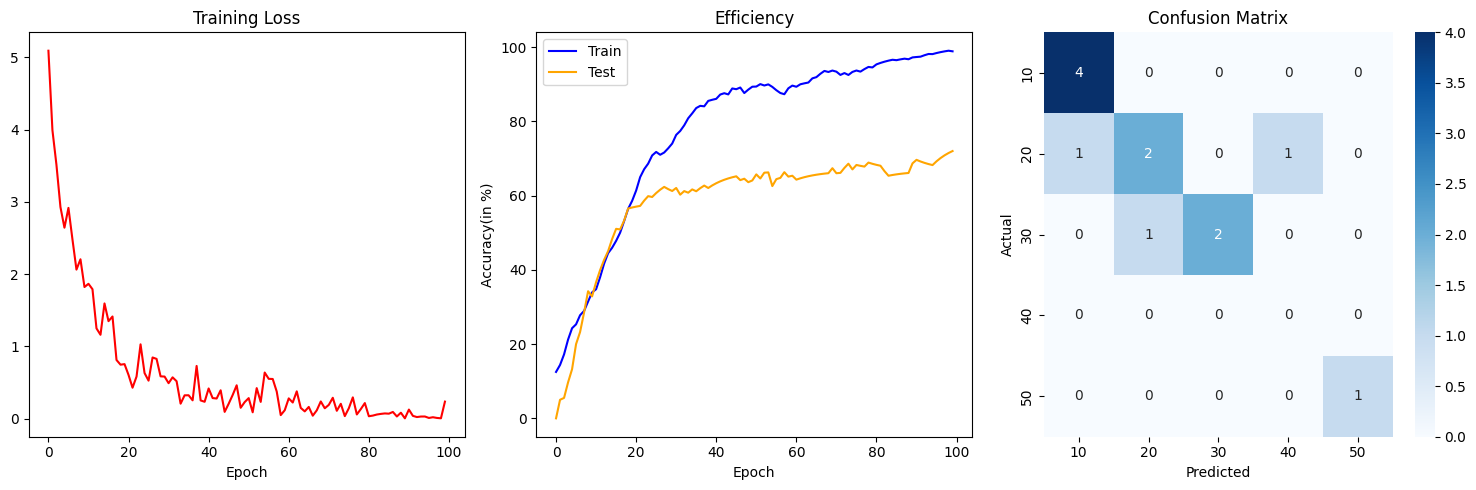

In [ ]:
# 1. Print F1 Score & Report
print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=CLASSES, labels=list(range(len(CLASSES)))))

# 2. Plot Smoothed Accuracy Curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['loss'], color='red')
plt.title('Training Loss'); plt.xlabel('Epoch')

plt.subplot(1, 3, 2)
# --- MODIFIED: Removed raw lines, kept only smoothed lines ---
plt.plot(smoothen(history['train_acc']), color='blue', label='Train')
plt.plot(smoothen(history['test_acc']), color='orange', label='Test')
plt.title('Efficiency'); plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Accuracy(in %)')

# 3. Plot Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')

plt.tight_layout()
plt.show()